# 5b. Visualising the source estimates (2D fallback, no pyvista)

Notebook 05 plots the source estimates with `stc.plot()`, which needs the pyvista/VTK 3D
backend (`mne.viz.set_3d_backend`) and off-screen OpenGL rendering. On some machines this
pipeline is not usable at all - no GPU driver, no working OpenGL context, a Binder/JupyterHub
image without the right system libraries, and so on.

This notebook produces the same plots from the same precomputed results (the `.stc` files,
the morph, and the fsaverage surfaces), using **only matplotlib** via
`nilearn.plotting.plot_surf_stat_map` / `plot_surf_roi` with `engine="matplotlib"`. Those
functions render the cortical mesh with matplotlib's built-in 3D toolkit (`mplot3d`) instead
of pyvista/VTK, so there is no dependency on pyvista, VTK, trame or a GPU at all. The
trade-off: static lateral views instead of an interactive, rotatable, time-scrubbing brain.

In [1]:
# imports - no pyvista, no mne.viz.set_3d_backend
import os

import numpy as np
import matplotlib.pyplot as plt
from nibabel.freesurfer.io import read_morph_data

import mne
from nilearn.plotting import plot_surf_stat_map, plot_surf_roi

print("MNE:", mne.__version__)

# data paths - same prefix as in notebooks 04 and 05
subID = 24
data_path = "data"
subject_path = os.path.join(f"sub-0{subID}", "ses-mecha", "eeg")
base = os.path.join("..", data_path, subject_path, f"sub-0{subID}_ses-mecha_task-NT_")

# fsaverage: downloads it on first use, otherwise just returns the path
fs_dir = mne.datasets.fetch_fsaverage()
subjects_dir = os.path.dirname(fs_dir)
print(subjects_dir)

MNE: 1.11.0
0 files missing from root.txt in /data/tu_grossmannr/mne_data/MNE-fsaverage-data
0 files missing from bem.txt in /data/tu_grossmannr/mne_data/MNE-fsaverage-data/fsaverage
/data/tu_grossmannr/mne_data/MNE-fsaverage-data


## Morphing to fsaverage

Same as notebook 05: the individual MRI is not part of this dataset, so we morph the
source estimate onto *fsaverage* using the precomputed morph.

In [2]:
# load the source estimate and the precomputed morph
stc = mne.read_source_estimate(base + "MNE-all")
morph = mne.read_source_morph(base + "morph.h5")

# apply the morph: individual source space -> fsaverage
stc_fs = morph.apply(stc)
print(stc_fs)

<SourceEstimate | 20484 vertices, subject : fsaverage, tmin : -470.0 (ms), tmax : 430.00000000000006 (ms), tstep : 2.0 (ms), data shape : (20484, 451), ~35.4 MiB>


### From source space to surface mesh

`stc_fs` lives on the fsaverage *source space*: 10242 vertices per hemisphere (ico-5). The
fsaverage *surface mesh* we are about to paint it on has 163842. Dropping the estimate
straight onto that mesh would leave 15 of every 16 vertices at zero, and since nilearn
colours each triangle by the mean of its three corners, the map would come out diluted and
speckled instead of showing contiguous blobs.

Morphing fsaverage onto itself with `spacing=None` spreads the values over every vertex of
the mesh. `smooth` is the number of smoothing steps - the same thing `stc.plot()` does for
us internally, where the default is also 10.

In [3]:
morph_surface = mne.compute_source_morph(
    stc_fs,
    subject_from="fsaverage",
    subject_to="fsaverage",
    spacing=None,  # None = keep every vertex of the target surface
    smooth=10,
    subjects_dir=subjects_dir,
)
stc_surf = morph_surface.apply(stc_fs)
print(stc_surf)

surface source space present ...
Computing morph matrix...
    Left-hemisphere map read.
    Right-hemisphere map read.
    10 smooth iterations done.
    10 smooth iterations done.
[done]
[done]
<SourceEstimate | 327684 vertices, subject : fsaverage, tmin : -470.0 (ms), tmax : 430.00000000000006 (ms), tstep : 2.0 (ms), data shape : (327684, 451), ~566.3 MiB>


## Helpers

Two things `stc.plot()` normally does for us under the hood:

- read the cortical surface mesh (coordinates + triangles) - here via `mne.read_surface`,
  a pure Python/nibabel reader, no VTK involved.
- hand one hemisphere's values for one time point to the renderer. After the morph above
  `stc_surf` has exactly one value per surface vertex, so `lh_data` / `rh_data` line up with
  the mesh row by row.

In [4]:
def load_hemi_mesh(hemi):
    """Coordinates, triangles and sulcal-depth background map for one fsaverage hemisphere."""
    surf_dir = os.path.join(subjects_dir, "fsaverage", "surf")
    coords, faces = mne.read_surface(os.path.join(surf_dir, f"{hemi}.inflated"))
    sulc = read_morph_data(os.path.join(surf_dir, f"{hemi}.sulc"))
    return coords, faces, sulc


def hemi_data(stc, hemi, time_idx):
    """One hemisphere of a full-surface source estimate at one time point."""
    return (stc.lh_data if hemi == "lh" else stc.rh_data)[:, time_idx]


# cache the two hemisphere meshes - reused by every plot below
meshes = {hemi: load_hemi_mesh(hemi) for hemi in ("lh", "rh")}

# the two must match, otherwise the values do not belong to the vertices they are drawn on
print("mesh vertices:", meshes["lh"][0].shape[0], "- stc vertices:", len(stc_surf.vertices[0]))

mesh vertices: 163842 - stc vertices: 163842


In [5]:
def plot_stat_map_both_hemis(stc, time_idx, title, threshold, vmax):
    """Lateral view of both hemispheres for one time point, via nilearn's matplotlib engine.

    `threshold` and `vmax` are computed once by the caller and shared by both hemispheres,
    so the two brains are on the same colour scale and can be compared directly.

    The threshold is not optional. With `threshold=None`, nilearn keeps every vertex and
    draws the map fully opaque on top of `bg_map`, which buries the sulcal anatomy under a
    near-white overlay. `stc.plot()` hides this from us by thresholding at the 93rd
    percentile by default.
    """
    fig = plt.figure(figsize=(9, 4))
    for i, hemi in enumerate(("lh", "rh")):
        coords, faces, sulc = meshes[hemi]
        ax = fig.add_subplot(1, 2, i + 1, projection="3d")
        plot_surf_stat_map(
            [coords, faces], hemi_data(stc, hemi, time_idx), bg_map=sulc,
            hemi="left" if hemi == "lh" else "right", view="lateral",
            engine="matplotlib", axes=ax,
            threshold=threshold, vmax=vmax, symmetric_cbar=True,
            colorbar=(hemi == "rh"),  # one colour bar, since both hemispheres share the scale
        )
        ax.set_title(hemi)
    fig.suptitle(title)
    fig.subplots_adjust(wspace=0.0)
    return fig

## The brain plot

The static counterpart of notebook 05's `stc.plot()`: one lateral view per hemisphere at a
single time point, coloured by the (signed) source amplitude. No time slider here - we pick
the peak latency instead.

`stc.plot()` without a `clim` is not really unthresholded either: MNE's default is
`clim=dict(kind="percent", lims=[93, 97, 99.9])`. We pass the same percentiles to
`plot_surf_stat_map`, so this figure matches notebook 05's first brain.

peak at 186 ms


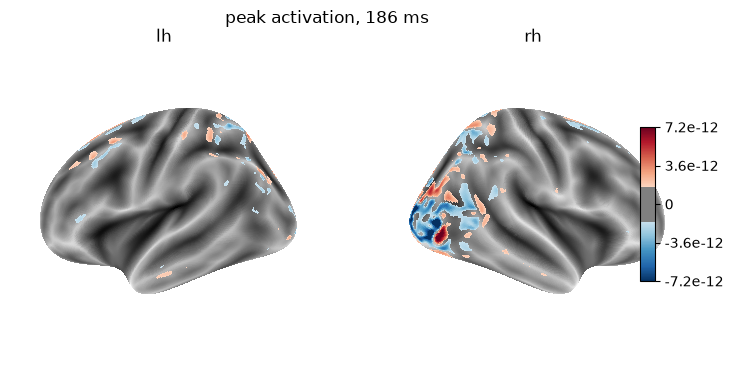

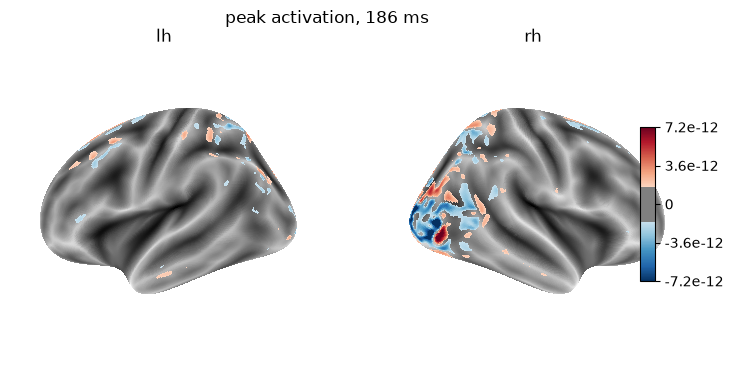

In [6]:
# when and where is the estimate largest?
peak_vertex, peak_time = stc_fs.get_peak(tmin=0.05, tmax=0.4)
peak_time_idx = stc_surf.time_as_index(peak_time)[0]
print(f"peak at {peak_time * 1000:.0f} ms")

# the percentiles have to come from the data we actually draw, i.e. the full-surface one
abs_values = np.abs(stc_surf.data[:, peak_time_idx])

plot_stat_map_both_hemis(
    stc_surf, peak_time_idx, f"peak activation, {peak_time * 1000:.0f} ms",
    threshold=np.percentile(abs_values, 93),
    vmax=np.percentile(abs_values, 99.9),
)

### Colour scale

Notebook 05 raises the limits to `clim=dict(kind="percent", pos_lims=[97, 99, 99.95])` to
show fewer, more focal sources. `plot_surf_stat_map` doesn't take the same `clim` dict, but
`threshold` and `vmax` give the same effect: values below the 97th percentile become
transparent, and the colour scale saturates at the 99.95th percentile. `symmetric_cbar=True`
(set inside our helper) mirrors the limits to the negative side, since our estimates are
signed.

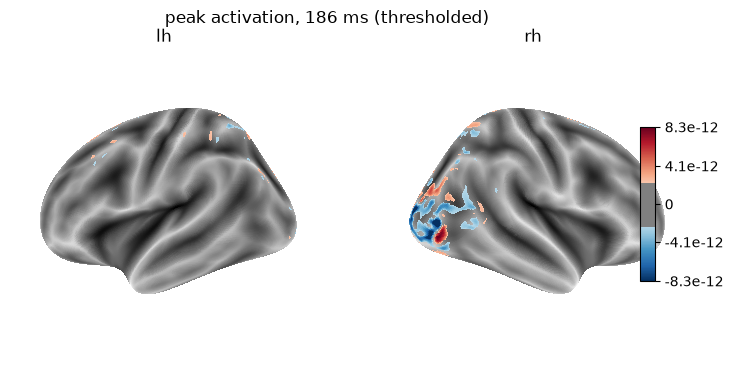

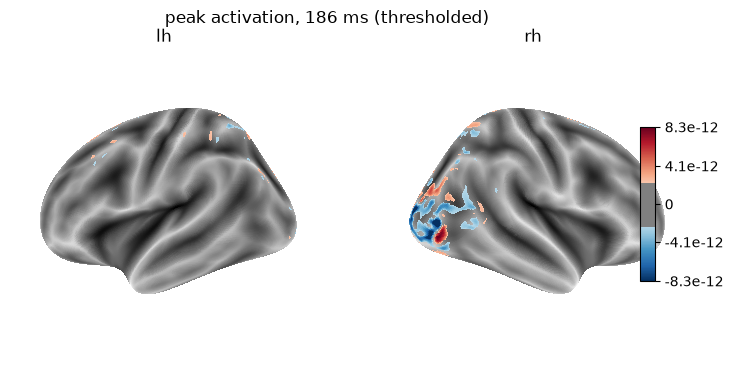

In [7]:
threshold = np.percentile(abs_values, 97)
vmax = np.percentile(abs_values, 99.95)

plot_stat_map_both_hemis(
    stc_surf, peak_time_idx, f"peak activation, {peak_time * 1000:.0f} ms (thresholded)",
    threshold=threshold, vmax=vmax,
)

## Time course of a single source

Same as notebook 05 - this is already plain matplotlib and needs no fallback.

strongest source: row 10684 (rh), peaking at 186 ms


Text(0.5, 1.0, 'peak source (rh)')

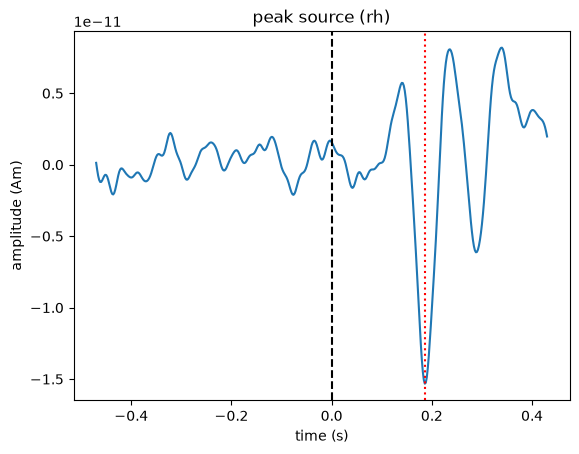

In [8]:
peak_idx, peak_time = stc_fs.get_peak(tmin=0.05, tmax=0.4, vert_as_index=True)
n_lh = len(stc_fs.vertices[0])
hemi = "lh" if peak_idx < n_lh else "rh"
print(f"strongest source: row {peak_idx} ({hemi}), peaking at {peak_time * 1000:.0f} ms")

plt.plot(stc_fs.times, stc_fs.data[peak_idx])
plt.axvline(0, color="k", linestyle="--")
plt.axvline(peak_time, color="r", linestyle=":")
plt.xlabel("time (s)")
plt.ylabel("amplitude (Am)")
plt.title(f"peak source ({hemi})")

## Anatomical parcels

Same `aparc` parcellation and `mean_flip` label extraction as notebook 05 - none of this
needs pyvista either, only the "where do these labels sit" brain plot does.

In [9]:
# the parcellation and the source space it is defined on
labels = mne.read_labels_from_annot("fsaverage", parc="aparc", subjects_dir=subjects_dir)
src_fs = mne.read_source_spaces(
    os.path.join(subjects_dir, "fsaverage", "bem", "fsaverage-ico-5-src.fif")
)

# a few regions that are plausible for a tactile detection task
roi_names = ["postcentral-lh", "postcentral-rh", "superiorparietal-lh", "precuneus-lh"]
rois = [label for label in labels if label.name in roi_names]

label_tc = mne.extract_label_time_course(stc_fs, rois, src_fs, mode="mean_flip")
print("label time courses:", label_tc.shape)

Reading labels from parcellation...
   read 35 labels from /data/tu_grossmannr/mne_data/MNE-fsaverage-data/fsaverage/label/lh.aparc.annot
   read 34 labels from /data/tu_grossmannr/mne_data/MNE-fsaverage-data/fsaverage/label/rh.aparc.annot
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    2 source spaces read
Extracting time courses for 4 labels (mode: mean_flip)
label time courses: (4, 451)


Text(0.5, 1.0, 'label time courses (mean_flip)')

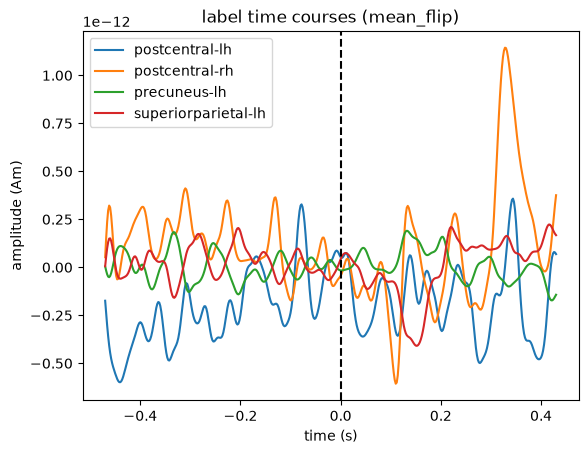

In [10]:
for name, time_course in zip([label.name for label in rois], label_tc):
    plt.plot(stc_fs.times, time_course, label=name)
plt.axvline(0, color="k", linestyle="--")
plt.xlabel("time (s)")
plt.ylabel("amplitude (Am)")
plt.legend()
plt.title("label time courses (mean_flip)")

ROIs, in colormap order:
  1: postcentral-lh
  2: postcentral-rh
  3: precuneus-lh
  4: superiorparietal-lh


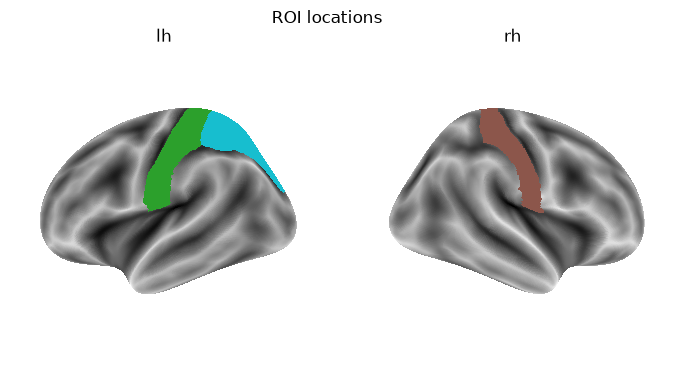

In [11]:
# where these labels sit on the brain
fig = plt.figure(figsize=(9, 4))
for i, hemi in enumerate(("lh", "rh")):
    coords, faces, sulc = meshes[hemi]
    # NaN, not 0: plot_surf_roi has no notion of a background value and would paint every
    # unlabelled vertex with the first colour of the colormap. NaN it masks out.
    roi_map = np.full(coords.shape[0], np.nan)
    for label_idx, label in enumerate(rois, start=1):
        if label.hemi == hemi:
            roi_map[label.vertices] = label_idx

    ax = fig.add_subplot(1, 2, i + 1, projection="3d")
    plot_surf_roi(
        [coords, faces], roi_map, bg_map=sulc,
        hemi="left" if hemi == "lh" else "right", view="lateral",
        engine="matplotlib", axes=ax, cmap="tab10", vmin=0, vmax=len(rois),
        colorbar=False,
    )
    ax.set_title(hemi)
fig.suptitle("ROI locations")
fig.subplots_adjust(wspace=0.0)

# precuneus sits on the medial wall, so it does not show up in a lateral view
print("ROIs, in colormap order:")
for label_idx, label in enumerate(rois, start=1):
    print(f"  {label_idx}: {label.name}")

## The contrast

The perceived-minus-unperceived contrast, morphed to fsaverage, plotted the same way as the
activation maps above.

largest difference at 148 ms


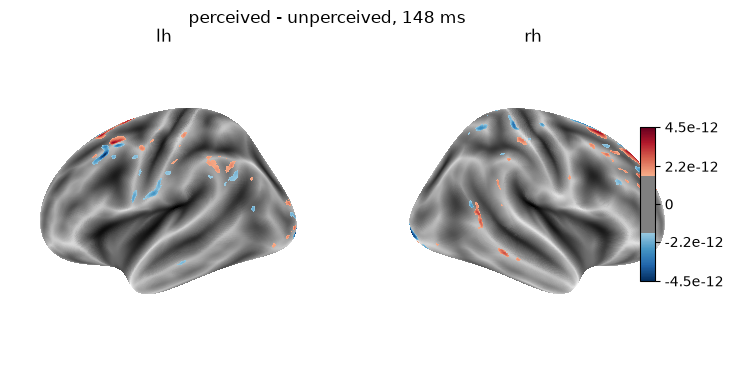

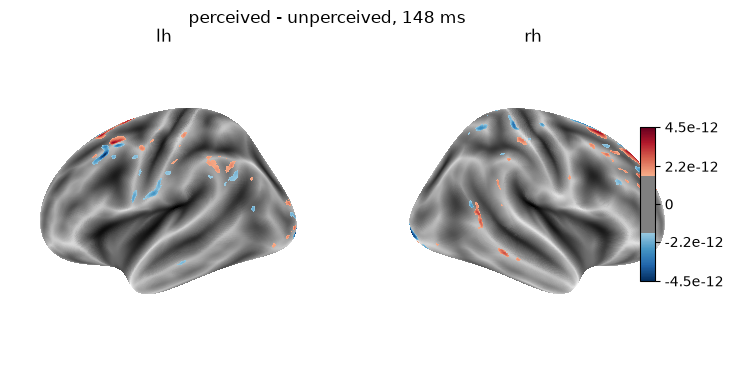

In [12]:
stc_difference = mne.read_source_estimate(base + "MNE-difference")
stc_difference_fs = morph.apply(stc_difference)
stc_difference_surf = morph_surface.apply(stc_difference_fs)

diff_vertex, diff_time = stc_difference_fs.get_peak(tmin=0.05, tmax=0.4)
diff_time_idx = stc_difference_surf.time_as_index(diff_time)[0]
print(f"largest difference at {diff_time * 1000:.0f} ms")

diff_abs_values = np.abs(stc_difference_surf.data[:, diff_time_idx])

plot_stat_map_both_hemis(
    stc_difference_surf, diff_time_idx, f"perceived - unperceived, {diff_time * 1000:.0f} ms",
    threshold=np.percentile(diff_abs_values, 97),
    vmax=np.percentile(diff_abs_values, 99.95),
)